
# Calculus and Differential Equations for Neural Dynamics


This notebook is the **hands-on companion** to the lecture on `Calculus and Differential Equations for Neural Dynamics` for the **Mathematical Modeling for Brain Data (MAMBA) Workshop**



## Learning goals

By the end, you should be able to:
1. Explain, in plain language, what a **rate of change** is.
2. Read a differential equation as a **rule for evolution**, not a formula solved once.
3. Find a system's **equilibrium** and determine whether it's **stable**.
4. Explain why biological systems **leak** back toward a resting state.
5. Apply the same building blocks to a **single neuron** (LIF) and a **population** (Wilson-Cowan).
6. **Simulate** any of these models, and know when to add **randomness**.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

TEAL, TERRACOTTA, AMBER, OLIVE, INK = "#0F766E", "#C2410C", "#A16207", "#4D7C0F", "#241F1C"



---
## 1. Why change over time matters


A single reading of membrane potential (e.g: −58.3 mV) tells you almost nothing:
is the neuron about to fire? Recovering from a spike? Resting? What matters is the **trajectory**:
which way it's heading, and how fast.


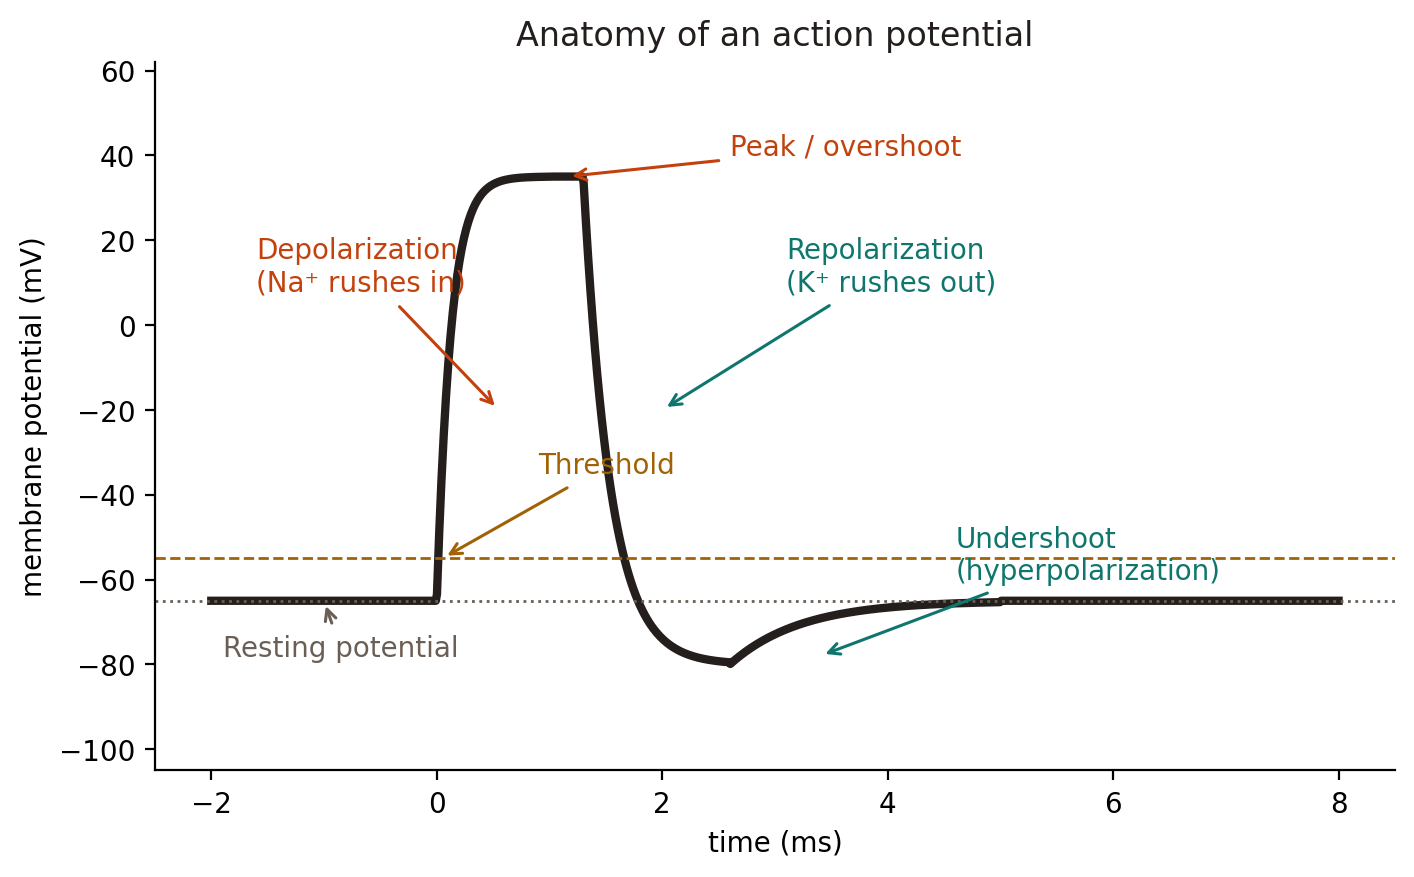

*Membrane potential is never just a number, it's a trajectory with phases.


Almost nothing interesting in the nervous system is static. A neurotransmitter concentration
rises after release and falls as it's cleared. A population's firing rate ramps up during a
decision and back down after. A synaptic weight strengthens slowly over hours of learning. In
every case, the interesting biology is encoded in **how** the quantity changes, which is
exactly what calculus and differential equations describe.

**Key idea:** a model of a static snapshot tells you what a system looks like right now. A model
of change over time tells you what it will do **next**.


V at one instant: -58.3 mV   <-- tells us almost nothing on its own


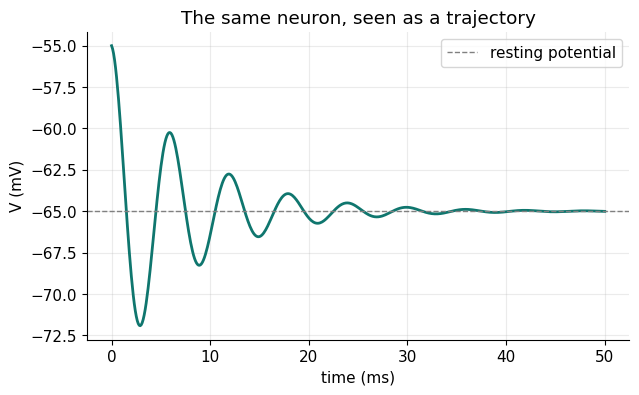

In [ ]:

# A single "snapshot" of membrane potential tells us almost nothing...
V_snapshot = -58.3
print(f"V at one instant: {V_snapshot} mV   <-- tells us almost nothing on its own")

# ...versus the full trajectory, which shows the behaviour we actually care about
t = np.linspace(0, 50, 500)
V_trace = -65 + 10 * np.exp(-t / 8) * np.cos(2 * np.pi * t / 6)

plt.plot(t, V_trace, color=TEAL, lw=2)
plt.axhline(-65, color="gray", ls="--", lw=1, label="resting potential")
plt.xlabel("time (ms)"); plt.ylabel("V (mV)")
plt.title("The same neuron, seen as a trajectory")
plt.legend(); plt.show()



---
## 2. Variables, parameters, and functions



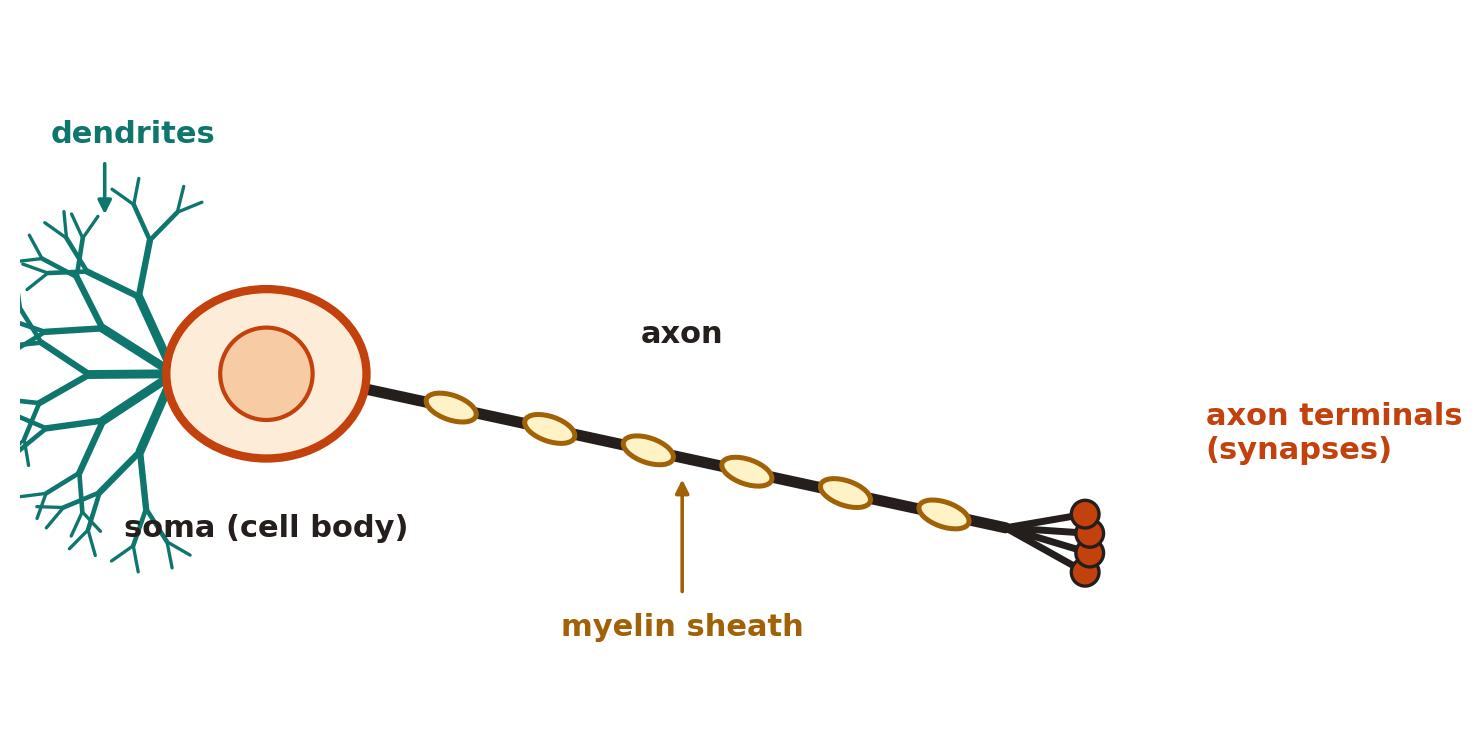

*Every part of this neuron plays one of two roles in a model: a VARIABLE (changes moment to moment) or a PARAMETER (fixed, describes this particular neuron).*


- **Variable** : changes over time: membrane potential $V(t)$, firing rate $r(t)$, a gating
  variable $n(t)$.
- **Parameter** : a fixed number chosen in advance: the membrane time constant $\tau$, the
  resting potential $V_{rest}$, a synaptic weight, a threshold.
- **Function** : the rule connecting them, e.g. $\dfrac{dV}{dt} = F(V, t)$.


In [ ]:

def dVdt(V, tau=10.0, V_rest=-65.0):
    """The rate-of-change RULE. V is the variable; tau and V_rest are parameters."""
    return -(V - V_rest) / tau

# Evaluate the rule at different values of V
for V in [-90, -65, -40]:
    print(f"V = {V:>4} mV   ->   dV/dt = {dVdt(V):+.2f} mV/ms")


V =  -90 mV   ->   dV/dt = +2.50 mV/ms
V =  -65 mV   ->   dV/dt = -0.00 mV/ms
V =  -40 mV   ->   dV/dt = -2.50 mV/ms



Notice the sign: below rest, `dV/dt` is positive (pushing V up); above rest, it's negative
(pushing V down); at rest, it's exactly zero. That pattern — a rule that always pushes back
toward one value — is the **leaky** behaviour we return to in Sections 5–7.



> **Try it yourself:** write a second rule, `dndt(n, tau_n=5.0, n_inf=0.3)`, for a channel gating variable relaxing toward `n_inf`. Evaluate it at `n=0` and `n=1` — does the sign make sense?


<details>
<summary>Question: in `dVdt(V, tau, V_rest)`, which arguments are parameters, and which is the variable?</summary>

*(`tau` and `V_rest` are parameters; `V` is the variable.)*

</details>


---
## 3. Rate of change: slope and derivative



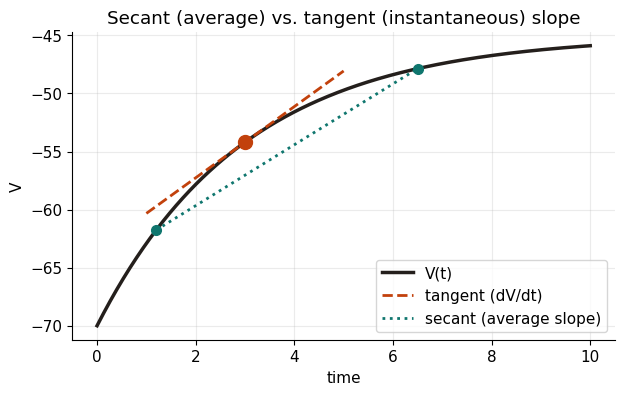

In [ ]:

# Illustrate secant -> tangent directly
tt = np.linspace(0, 10, 300)
y = -70 + 25 * (1 - np.exp(-tt / 3))

t0 = 3.0
y0 = -70 + 25 * (1 - np.exp(-t0 / 3))
slope = 25 / 3 * np.exp(-t0 / 3)          # exact derivative at t0
ttl = np.linspace(t0 - 2, t0 + 2, 10)

t1, t2 = 1.2, 6.5                          # two points for the secant
y1 = -70 + 25 * (1 - np.exp(-t1 / 3))
y2 = -70 + 25 * (1 - np.exp(-t2 / 3))

plt.plot(tt, y, color=INK, lw=2.5, label="V(t)")
plt.plot(ttl, y0 + slope * (ttl - t0), "--", color=TERRACOTTA, lw=2, label="tangent (dV/dt)")
plt.plot([t1, t2], [y1, y2], ":", color=TEAL, lw=2, label="secant (average slope)")
plt.plot([t0], [y0], "o", color=TERRACOTTA, ms=10)
plt.plot([t1, t2], [y1, y2], "o", color=TEAL, ms=7)
plt.xlabel("time"); plt.ylabel("V"); plt.legend()
plt.title("Secant (average) vs. tangent (instantaneous) slope")
plt.show()



**Plain-language definition:** positive derivative → V rising right now. Negative → falling
right now. Zero → momentarily flat.

Real recordings are sampled, not continuous, so in practice we estimate the derivative with a
**finite difference**, the slope between consecutive samples.


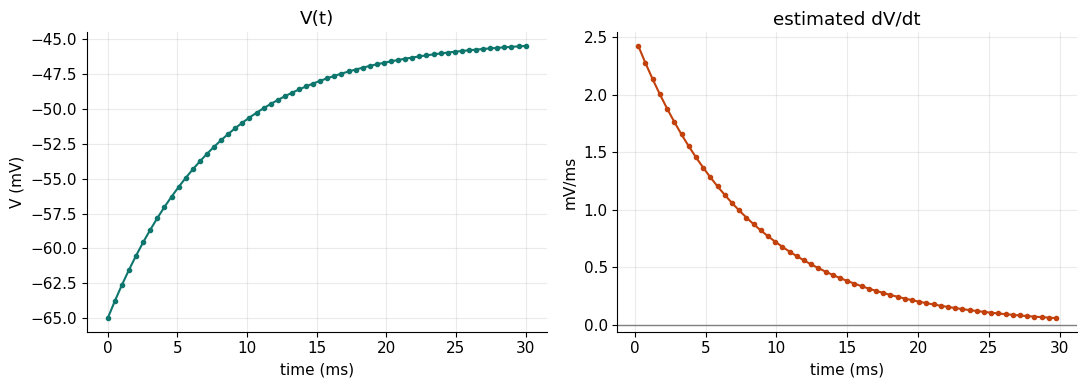

In [ ]:

# Sample a smooth curve, then estimate its derivative from the samples alone
t = np.linspace(0, 30, 60)
V = -65 + 20 * (1 - np.exp(-t / 8))          # a relaxation curve

dVdt_est = np.diff(V) / np.diff(t)           # finite-difference derivative
t_mid = (t[:-1] + t[1:]) / 2                 # midpoints, for plotting

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, V, "o-", ms=3, color=TEAL)
ax[0].set_title("V(t)"); ax[0].set_xlabel("time (ms)"); ax[0].set_ylabel("V (mV)")
ax[1].plot(t_mid, dVdt_est, "o-", ms=3, color=TERRACOTTA)
ax[1].axhline(0, color="gray", lw=1)
ax[1].set_title("estimated dV/dt"); ax[1].set_xlabel("time (ms)"); ax[1].set_ylabel("mV/ms")
plt.tight_layout(); plt.show()



Notice `dV/dt` starts large and positive (V is rising fast) and shrinks toward zero as V levels
off : the slope of the left curve *is* the height of the right curve, point for point. This
mechanistic reading matters: each current (leak, synaptic, voltage-gated) contributes to the
instantaneous slope of V, and summing those contributions is exactly what a differential
equation for V does.


> **Try it yourself:** generate a noisy voltage trace (`V + np.random.normal(0, 0.5, size=V.shape)`)
> and re-run the finite-difference estimate. What happens to the derivative estimate? Why?



---
## 4. Differential equations as rules for evolution




A differential equation doesn't hand you $V$ directly : it hands you a **rule** for which way
$V$ is currently heading. Solving it means repeatedly applying that rule: *look at where you
are, compute the slope, take a small step, then repeat.* That repeated process is exactly what a
simulation does (formalized in Section 10).

$$\frac{dV}{dt} = F(V, t;\ \text{parameters}) \quad\longrightarrow\quad \text{solving for } V(t),\ \text{the whole trajectory}$$



In [ ]:

# "Reading" the rule as a sentence, at a few states
V_rest, tau = -65.0, 10.0
for V in [-85, -65, -45]:
    push = dVdt(V, tau=tau, V_rest=V_rest)
    direction = "toward rest (+)" if push > 0 else ("toward rest (-)" if push < 0 else "at rest")
    print(f"At V={V:>4} mV: rule says dV/dt={push:+.2f} mV/ms  ->  pushing {direction}")


At V= -85 mV: rule says dV/dt=+2.00 mV/ms  ->  pushing toward rest (+)
At V= -65 mV: rule says dV/dt=-0.00 mV/ms  ->  pushing at rest
At V= -45 mV: rule says dV/dt=-2.00 mV/ms  ->  pushing toward rest (-)



A differential equation **plus** an initial condition ($V(0)$) together determine the entire
future trajectory. Two neurons obeying the same equation but starting from different $V(0)$
follow different paths — but, as we'll see in Sections 6–7, they often converge to the same
long-run behaviour anyway.




---
## 5. First-order equations: growth, decay, relaxation


Three canonical patterns cover most of what you'll meet:

$$\text{Growth: } \frac{dx}{dt}=kx \qquad \text{Decay: } \frac{dx}{dt}=-kx \qquad
\text{Relaxation: } \frac{dV}{dt}=-\frac{V-V_{eq}}{\tau}$$


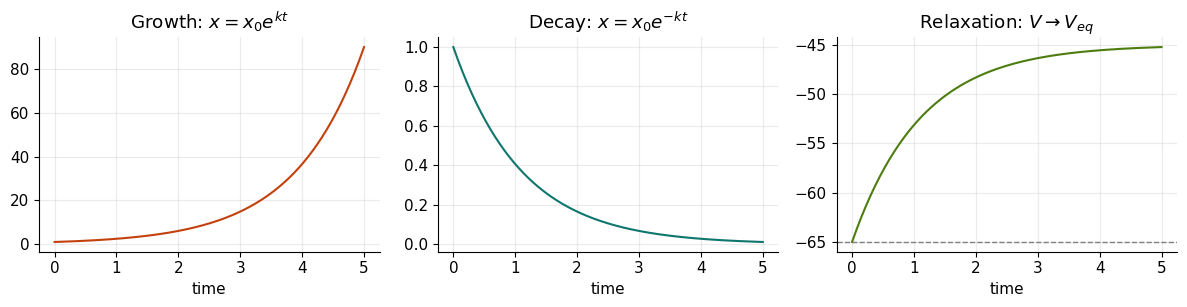

In [ ]:

t = np.linspace(0, 5, 200)
growth = np.exp(0.9 * t)
decay = np.exp(-0.9 * t)
relax = -65 + 20 * (1 - np.exp(-0.9 * t))       # relaxes toward V_eq = -65

fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].plot(t, growth, color=TERRACOTTA); ax[0].set_title(r"Growth: $x=x_0 e^{kt}$")
ax[1].plot(t, decay, color=TEAL); ax[1].set_title(r"Decay: $x=x_0 e^{-kt}$")
ax[2].plot(t, relax, color=OLIVE); ax[2].axhline(-65, color="gray", ls="--", lw=1)
ax[2].set_title(r"Relaxation: $V\to V_{eq}$")
for a in ax: a.set_xlabel("time")
plt.tight_layout(); plt.show()



**Growth** ($k>0$): rate grows with the value itself : e.g. the fast, self-reinforcing opening of Na⁺ channels at the start of a spike.

**Decay** ($k>0$): shrinks back toward zero :  e.g. neurotransmitter clearance from the synaptic cleft.

**Relaxation:** decays toward a non-zero target $V_{eq}$, our anchor equation generalized.

**The "five-tau" rule:** after $1\tau$, a relaxation process is ≈63% of the way to
equilibrium; after $3\tau$, ≈95%; after $5\tau$, effectively fully settled (≈99%). This is
a fast, practical way to estimate how long a simulation needs to run.




<details>
<summary>a relaxation process has $\tau=20$ ms. Roughly how long until it's essentially fully settled? </summary>


*(About 5τ, so ≈100 ms.)*
</details>


---
## 6. Equilibrium points and stability



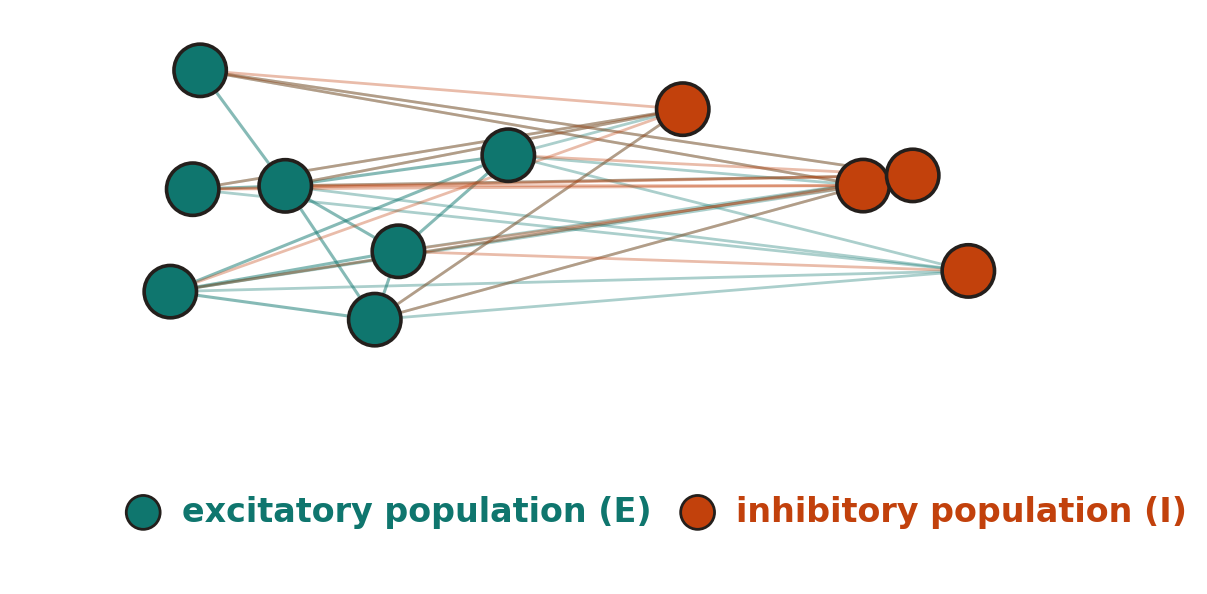

*A resting network isn't an absence of activity, it's a balance. Excitatory (teal) and inhibitory (terracotta) connections constantly push and pull; stability means small nudges get corrected.*


An **equilibrium** (fixed point, steady state) is a value where the rate of change is exactly
zero: $\left.\frac{dx}{dt}\right|_{x=x^*} = 0$. For our anchor equation, setting the right-hand
side to zero gives $V^* = V_{rest}$ : the resting potential *is* the equilibrium, by
construction.

**Stability** asks what happens when the system is nudged away:
- **Stable:** perturbations shrink back (like a ball resting in a valley).
- **Unstable:** perturbations grow away (like a ball balanced on a hilltop).

For $\frac{dx}{dt} = a\cdot(x-x^*)$, the equilibrium is stable if $a<0$, unstable if $a>0$.


In [ ]:

def find_equilibria(F, x_range, n=2000):
    x = np.linspace(*x_range, n)
    rate = F(x)
    idx = np.where(np.diff(np.sign(rate)))[0]
    return [(x[i], "stable" if rate[i] > 0 > rate[i + 1] else "unstable") for i in idx]

stable_eqs = find_equilibria(lambda V: dVdt(V), x_range=(-100, -30))
print("Leaky equation dV/dt = -(V-V_rest)/tau  ->", stable_eqs)

unstable_eqs = find_equilibria(lambda V: 0.1 * (V - (-65)), x_range=(-100, -30))
print("Runaway equation  dV/dt = +0.1*(V-V_rest) ->", unstable_eqs)


Leaky equation dV/dt = -(V-V_rest)/tau  -> [(np.float64(-65.01750875437719), 'stable')]
Runaway equation  dV/dt = +0.1*(V-V_rest) -> [(np.float64(-65.01750875437719), 'unstable')]


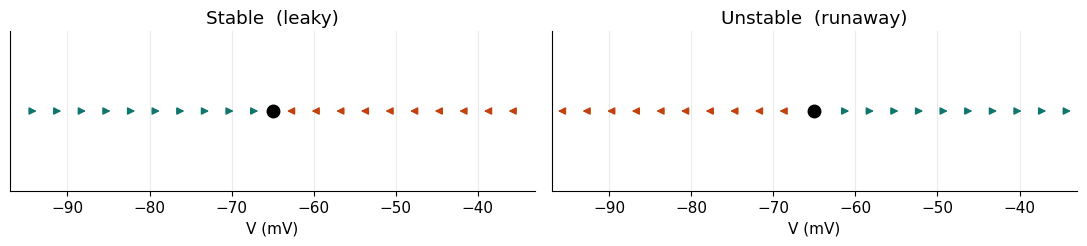

In [ ]:

# Visualize both as phase lines: arrows show which way V moves at each point.
# IMPORTANT: explicitly set xlim, or matplotlib may autoscale to only the
# equilibrium dot and clip most of the arrows out of view.
fig, ax = plt.subplots(1, 2, figsize=(11, 2.6))
V = np.linspace(-95, -35, 21)

for a, F, title in zip(ax, [lambda V: dVdt(V), lambda V: 0.1 * (V - (-65))],
                        ["Stable  (leaky)", "Unstable  (runaway)"]):
    rate = F(V)
    for v, r in zip(V, rate):
        if abs(r) < 1e-6: continue
        a.annotate("", xy=(v + np.sign(r) * 1.6, 0), xytext=(v, 0),
                   arrowprops=dict(arrowstyle="-|>", color=TEAL if r > 0 else TERRACOTTA))
    a.plot([-65], [0], "ko", ms=9)
    a.set_xlim(V.min() - 2, V.max() + 2)
    a.set_title(title); a.set_yticks([]); a.set_xlabel("V (mV)")
plt.tight_layout(); plt.show()



In almost every model you'll meet, you can identify qualitative behaviour just by asking two
questions: **(1)** where is $dx/dt=0$? **(2)** does the system move toward or away from that
point? Often you can answer both without solving the equation explicitly.


> **Try it yourself:** modify `find_equilibria` to also report the *slope* of `rate` at each
> equilibrium (a finite-difference estimate). Does its sign match the stability classification?



---
## 7. Leaky dynamics and the resting state


"Leaky" is the word for exactly the relaxation behaviour from Section 5: a system that drifts
back toward a fixed resting value, at a rate proportional to how far away it currently sits. The
name comes directly from real **leak channels**, always at least slightly open, constantly
letting ions flow down their concentration gradients, pulling V back toward rest.


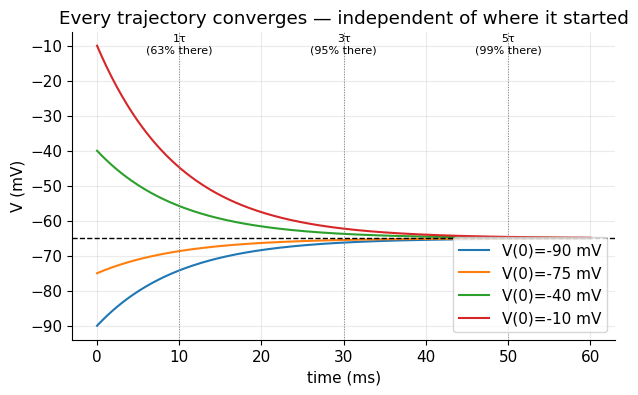

In [ ]:

def relaxation_analytic(t, x0, x_eq, tau):
    return x_eq + (x0 - x_eq) * np.exp(-t / tau)

tau = 10.0
t = np.linspace(0, 60, 300)
for V0 in [-90, -75, -40, -10]:
    plt.plot(t, relaxation_analytic(t, V0, -65, tau), label=f"V(0)={V0} mV")

plt.axhline(-65, color="k", ls="--", lw=1)
for k, frac in [(1, "63%"), (3, "95%"), (5, "99%")]:
    plt.axvline(k * tau, color="gray", lw=0.7, ls=":")
    plt.text(k * tau, -12, f"{k}\u03c4\n({frac} there)", fontsize=8, ha="center")
plt.legend(loc="lower right"); plt.xlabel("time (ms)"); plt.ylabel("V (mV)")
plt.title("Every trajectory converges — independent of where it started")
plt.show()



Any first-order variable of the leaky form $\frac{dx}{dt} = -\frac{x - x_{eq}}{\tau}$ shows three
properties, no matter what $x$ represents biologically:

- **Self-correcting** : perturbations are automatically opposed, no external controller needed.
- **History-forgetting** : after ≈$5\tau$, the system "forgets" its initial condition.
- **Single time-scale** : one quantity, $\tau$, governs the whole approach; no oscillation, no overshoot.

This is why biology reaches for this pattern so often: it's intrinsically stable and
self-limiting, with the correction built directly into the equation's structure — no extra
machinery required.


> **Try it yourself:** name one biological mechanism (besides resting potential) that likely
> follows leaky dynamics — then write its equation in the same `dx/dt = -(x - x_eq)/tau` form.



---
## 8. Membrane potential models: leaky integrate-and-fire


We now assemble Sections 3–7 into an actual neuron model. Subthreshold, the LIF neuron's
dynamics are exactly the leaky relaxation equation, plus an input current term:

$$\tau \frac{dV}{dt} = -(V - V_{rest}) + R\,I(t)$$

If $I(t)=0$, this collapses exactly to plain leaky decay, and V settles at $V_{rest}$. On top we
bolt **one discrete rule**: when V reaches threshold $V_{th}$, record a spike and reset
$V \to V_{reset}$.


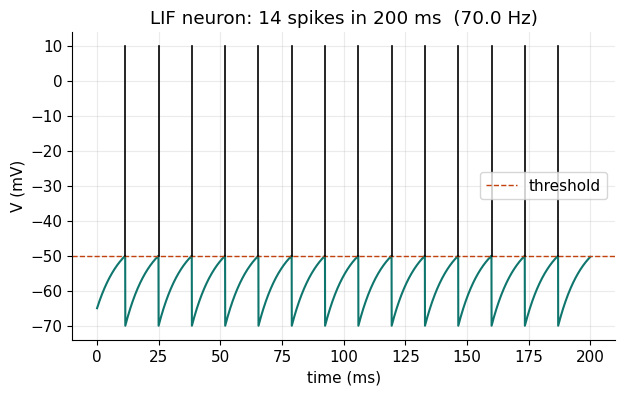

In [ ]:

def simulate_lif(I, T=200, dt=0.05, tau=10, Vrest=-65, Vth=-50, Vreset=-70, R=10):
    n = int(T / dt)
    V = np.zeros(n); V[0] = Vrest
    spike_times = []
    for i in range(1, n):
        dV = (-(V[i-1] - Vrest) + R * I) / tau
        V[i] = V[i-1] + dV * dt              # <- this line IS Euler's method (Section 10)
        if V[i] >= Vth:
            V[i] = Vreset
            spike_times.append(i * dt)
    return V, spike_times

V, spikes = simulate_lif(I=2.2)
t = np.arange(len(V)) * 0.05
plt.plot(t, V, color=TEAL)
plt.axhline(-50, color=TERRACOTTA, ls="--", lw=1, label="threshold")
for s in spikes: plt.plot([s, s], [-50, 10], color="k", lw=1.2)
plt.xlabel("time (ms)"); plt.ylabel("V (mV)"); plt.legend()
plt.title(f"LIF neuron: {len(spikes)} spikes in {t[-1]:.0f} ms  ({1000*len(spikes)/t[-1]:.1f} Hz)")
plt.show()


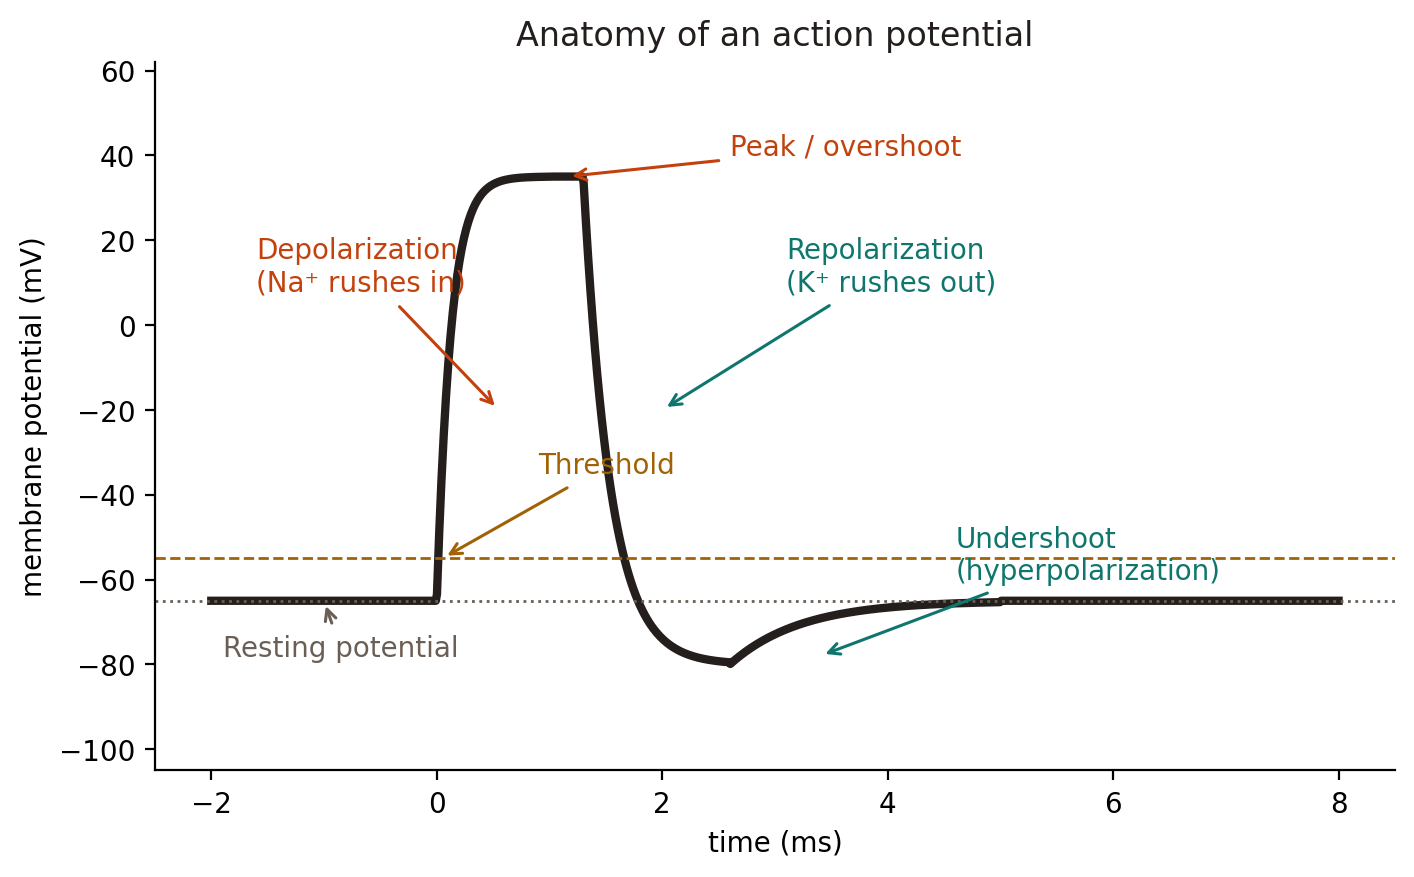

*The LIF model throws away this entire shape and replaces it with an instant vertical reset. That simplification keeps the TIMING of threshold crossings ,usually exactly the information a circuit-level question needs.*

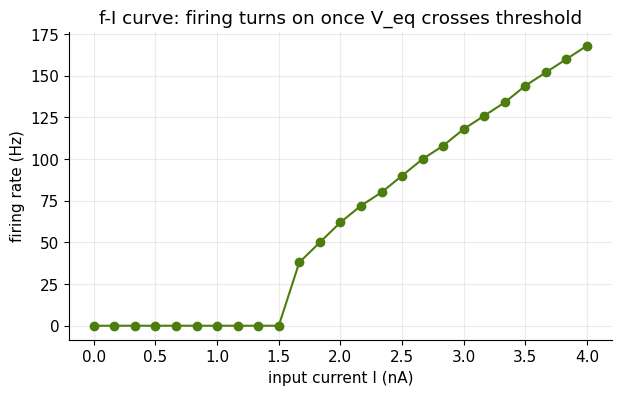

In [ ]:

I_values = np.linspace(0, 4, 25)
rates = []
for I in I_values:
    _, spikes = simulate_lif(I=I, T=500)
    rates.append(1000 * len(spikes) / 500)

plt.plot(I_values, rates, "o-", color=OLIVE)
plt.xlabel("input current I (nA)"); plt.ylabel("firing rate (Hz)")
plt.title("f-I curve: firing turns on once V_eq crosses threshold")
plt.show()




> **Try it yourself:** double `R` in `simulate_lif` and re-run the f-I sweep. Where does the
> "turn-on" current shift, and does it match the $V_{eq}=V_{rest}+R \cdot I$ prediction?




---
## 9. Neural population models


A single neuron's spike train is often not the right level of description for a whole circuit.
Population "rate models" track the **average firing rate** of a whole population as one
continuous variable, using the same leaky form:

$$\tau \frac{dr}{dt} = -r + f(\text{input})$$

The **Wilson-Cowan** model couples an excitatory (E) and inhibitory (I) population:

$$\tau_E \frac{dE}{dt} = -E + f(w_{EE}E - w_{EI}I + P) \qquad
\tau_I \frac{dI}{dt} = -I + f(w_{IE}E - w_{II}I)$$

Same family resemblance as the LIF equation: a leak term ($-E$, $-I$) opposed by a driven term
built from the *other* population's activity.


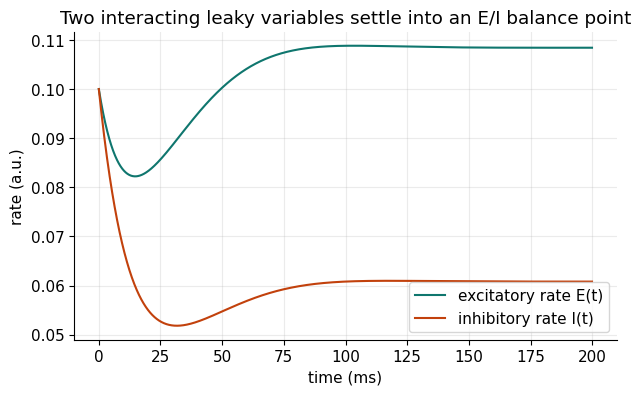

In [ ]:

def sigmoid(x, theta=4.0, a=1.0):
    return 1 / (1 + np.exp(-a * (x - theta)))

def simulate_wilson_cowan(P=1.2, T=200, dt=0.1, tauE=10, tauI=10,
                          wEE=12, wEI=10, wIE=10, wII=2, thE=4, thI=3.7):
    n = int(T / dt)
    E = np.zeros(n); I = np.zeros(n)
    E[0] = I[0] = 0.1
    for i in range(1, n):
        dE = (-E[i-1] + sigmoid(wEE*E[i-1] - wEI*I[i-1] + P, thE)) / tauE
        dI = (-I[i-1] + sigmoid(wIE*E[i-1] - wII*I[i-1], thI)) / tauI
        E[i] = E[i-1] + dt * dE
        I[i] = I[i-1] + dt * dI
    return E, I

E, I = simulate_wilson_cowan()
t = np.arange(len(E)) * 0.1
plt.plot(t, E, color=TEAL, label="excitatory rate E(t)")
plt.plot(t, I, color=TERRACOTTA, label="inhibitory rate I(t)")
plt.xlabel("time (ms)"); plt.ylabel("rate (a.u.)"); plt.legend()
plt.title("Two interacting leaky variables settle into an E/I balance point")
plt.show()


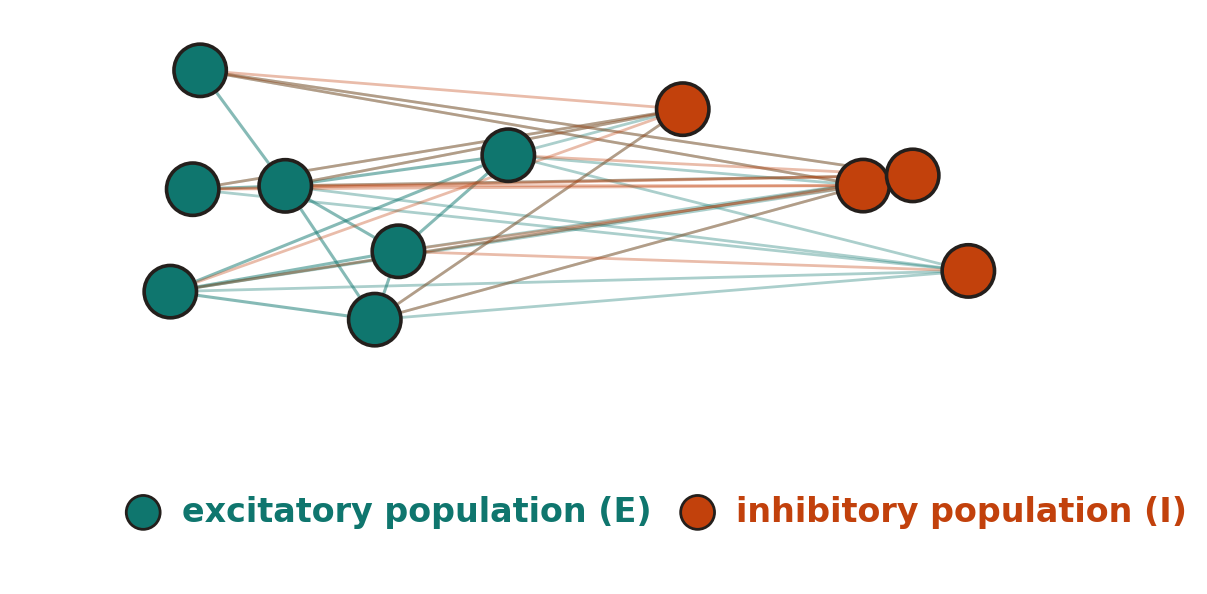

*Every connection here is a synapse like the one from Section 4. A population model doesn't track each one — it compresses millions of them into just four coupling weights: w_EE, w_EI, w_IE, w_II.*


Why does the jump from one variable to two matter? Because two interacting variables have a much
richer space of possible dynamics than one:

- **Multiple stable states** (bistability) : relevant to working memory, where a network holds
  one of several possible patterns after a stimulus disappears.
- **Sustained oscillations** : a single leaky variable can only ever relax smoothly to one
  equilibrium; oscillation requires the back-and-forth that (at least) two coupled variables
  provide.

> **✓ Checkpoint:** why can a single leaky variable never produce sustained oscillations?
> *(It always relaxes smoothly to one equilibrium; oscillation needs ≥ 2 coupled variables.)*

> **Try it yourself:** increase `wEI` (inhibition onto the excitatory population) in
> `simulate_wilson_cowan` and re-plot. Does the excitatory steady-state rate drop, as the
> leak-vs-drive intuition predicts?



---
## 10. Numerical approximation: how simulations work


For only a handful of especially simple equations can we write an exact formula for $V(t)$. For
almost everything realistic, we approximate numerically — and every simulation in this
notebook was already doing exactly this. **Euler's method:** compute the slope, take a small
step assuming it stays constant, land at a new point, repeat.

$$x(t + \Delta t) \approx x(t) + \Delta t \cdot \left.\frac{dx}{dt}\right|_t$$


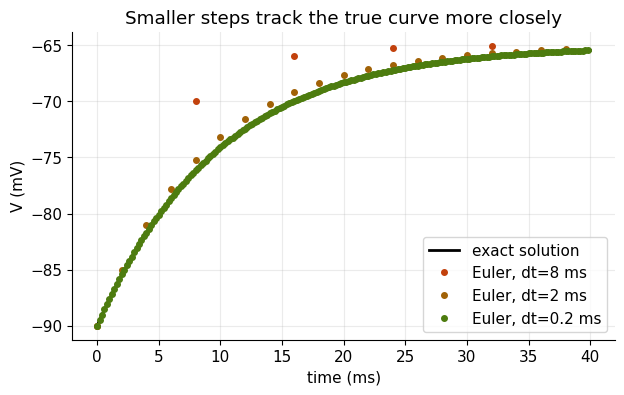

In [ ]:

def euler_integrate(F, x0, t):
    '''F(x, t) returns dx/dt; x0 is the initial condition; t is an array of times.'''
    x = np.zeros_like(t, dtype=float)
    x[0] = x0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        x[i] = x[i-1] + dt * F(x[i-1], t[i-1])
    return x

t_fine = np.linspace(0, 40, 400)
V_exact = relaxation_analytic(t_fine, -90, -65, tau=10)

plt.plot(t_fine, V_exact, "k-", lw=2, label="exact solution")
for step, color in zip([8, 2, 0.2], [TERRACOTTA, AMBER, OLIVE]):
    t_step = np.arange(0, 40, step)
    V_euler = euler_integrate(lambda V, tt: -(V - (-65)) / 10, -90, t_step)
    plt.plot(t_step, V_euler, "o", ms=4, color=color, label=f"Euler, dt={step} ms")
plt.legend(); plt.xlabel("time (ms)"); plt.ylabel("V (mV)")
plt.title("Smaller steps track the true curve more closely")
plt.show()



**Rule of thumb:** start with $dt \le \tau/20$, then confirm halving `dt` again barely changes
your results. Let's *quantify* that convergence instead of just eyeballing it: error vs. step
size, on log-log axes, should fall on a roughly straight line.


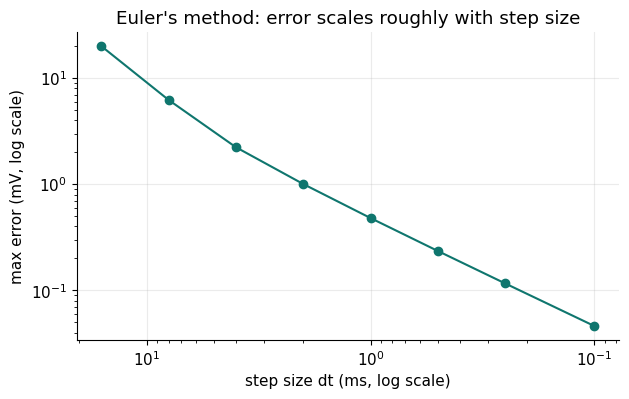

In [ ]:

# Quantify it: error shrinks (roughly linearly) as the step size shrinks
steps = np.array([16, 8, 4, 2, 1, 0.5, 0.25, 0.1])
errors = []
for step in steps:
    t_step = np.arange(0, 40, step)
    V_euler = euler_integrate(lambda V, tt: -(V - (-65)) / 10, -90, t_step)
    V_true = relaxation_analytic(t_step, -90, -65, tau=10)
    errors.append(np.max(np.abs(V_euler - V_true)))

plt.loglog(steps, errors, "o-", color=TEAL)
plt.xlabel("step size dt (ms, log scale)"); plt.ylabel("max error (mV, log scale)")
plt.title("Euler's method: error scales roughly with step size")
plt.gca().invert_xaxis()
plt.show()



---
## 11. Deterministic vs. stochastic models


Every model so far is **deterministic**: same equation, same start, same trajectory, every
single time. Real neurons are noisy : synaptic release is probabilistic, channels open and
close stochastically, background input looks effectively random. A **stochastic** model adds a
random "kick" at every step, scaled by $\sqrt{\Delta t}$ (not $\Delta t$ itself, so the total
injected randomness stays independent of your step size). This is the **Euler-Maruyama** method.


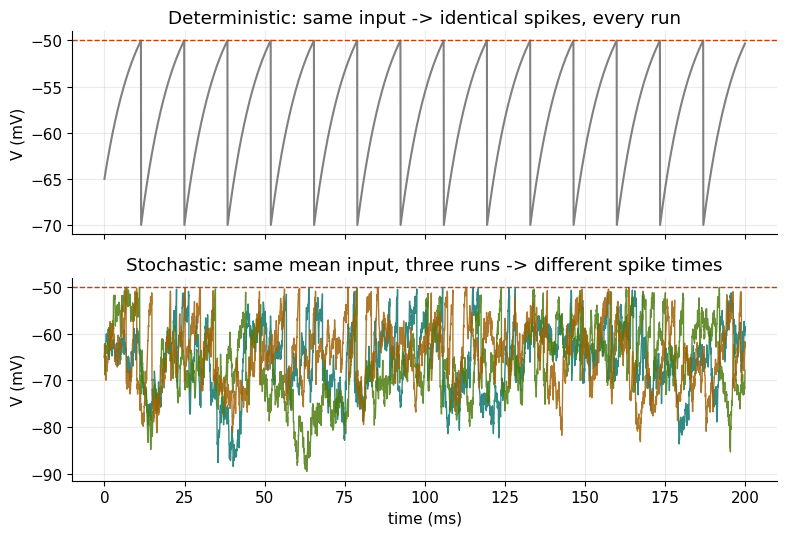

In [ ]:

def euler_maruyama(F, x0, t, sigma, rng):
    '''Stochastic version of euler_integrate: sigma sets noise strength.'''
    x = np.zeros_like(t, dtype=float)
    x[0] = x0
    for i in range(1, len(t)):
        dt = t[i] - t[i-1]
        noise = sigma * rng.standard_normal() * np.sqrt(dt)
        x[i] = x[i-1] + dt * F(x[i-1], t[i-1]) + noise
    return x

def simulate_lif_noisy(I, sigma, T=200, dt=0.05, tau=10, Vrest=-65,
                        Vth=-50, Vreset=-70, R=10, seed=None):
    rng = np.random.default_rng(seed)
    n = int(T / dt)
    V = np.zeros(n); V[0] = Vrest
    spikes = []
    for i in range(1, n):
        noise = sigma * rng.standard_normal() * np.sqrt(dt)
        dV = (-(V[i-1] - Vrest) + R * I) / tau
        V[i] = V[i-1] + dV * dt + noise
        if V[i] >= Vth:
            V[i] = Vreset
            spikes.append(i * dt)
    return V, spikes

fig, ax = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)
V_det, _ = simulate_lif(I=2.2)
t = np.arange(len(V_det)) * 0.05
ax[0].plot(t, V_det, color="gray"); ax[0].axhline(-50, color=TERRACOTTA, ls="--", lw=1)
ax[0].set_title("Deterministic: same input -> identical spikes, every run")

for seed, color in zip([1, 2, 3], [TEAL, OLIVE, AMBER]):
    V_n, _ = simulate_lif_noisy(I=2.2, sigma=6.0, seed=seed)
    ax[1].plot(t, V_n, color=color, lw=1, alpha=0.85)
ax[1].axhline(-50, color=TERRACOTTA, ls="--", lw=1)
ax[1].set_title("Stochastic: same mean input, three runs -> different spike times")
ax[1].set_xlabel("time (ms)")
for a in ax: a.set_ylabel("V (mV)")
plt.tight_layout(); plt.show()



A stochastic model's "equilibrium" generalizes into a **stationary distribution** , a spread
of likely values rather than one point. A common workflow: explore a circuit
deterministically first to understand its equilibria and stability, then add noise afterward to
test how robust that skeleton is.




---
## Synthesis, recap, and Q&A


Every model in this notebook ,from one ion channel's gating variable to a two-population
circuit, is built from the same small set of recurring ideas, reused at different scales:

1. **Identify** variables and parameters : what changes, and what's fixed.
2. **Write** the rate of change: $dx/dt = F(x,t)$ : read it as a sentence about competing pushes.
3. **Find equilibria** and **check stability** : set $dx/dt=0$; ask if nearby points are pushed
   toward or away.
4. **Recognize the leaky/relaxation form** : $dx/dt = -(x-x_{eq})/\tau$ — it is everywhere
   in neuroscience.
5. **Simulate** when no formula exists : Euler's method; shrink the step to check convergence.
6. **Choose** deterministic or stochastic : mean behaviour, or the variability itself?



### Summary table

| Idea | What to remember |
|---|---|
| Rate of change | The derivative is a speedometer — the instantaneous slope of a trajectory. |
| Differential equation | A rule for *which way* a variable is heading, not a formula for a fixed number. |
| Equilibrium | Where the rate of change is zero. Find it by setting $dx/dt=0$. |
| Stability | Stable if nearby points are pushed back; unstable if pushed away. |
| Leaky dynamics | $dx/dt=-(x-x_{eq})/\tau$ — self-correcting, forgets its start after $\sim5\tau$. |
| LIF neuron | Leaky relaxation + a threshold-reset rule bolted on top. |
| Population model | The same leak-vs-drive structure, with two (or more) interacting variables. |
| Euler's method | Step forward using the current slope; shrink `dt` until results stop changing. |
| Deterministic vs. stochastic | Same trajectory every time, vs. a distribution of possible trajectories. |


